# Project 2 — Descriptor EDA

This notebook explores the descriptor-based corrosion inhibition dataset.

Main goals:

1. Load clean datasets
2. Check dataset shapes and columns
3. Analyze Article 2 temperature-dependent target data
4. Analyze Article 3 molecule-level ranking data
5. Generate initial scientific observations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
project_path=Path('project2_descriptor')
raw_path=project_path/'data'/'raw'
processed_path=project_path/'data'/'processed'
reports_path=processed_path/'reports'
article2_clean_file=processed_path/'article2_clean_temperature_target_v1'
article3_clean_file=processed_path/'article3_clean_molecular_ranking_v1'

print("Project path:", project_path)
print("Raw path:", raw_path)
print("Processed path:", processed_path)
print("Article 2 clean file:", article2_clean_file)
print("Article 3 clean file:", article3_clean_file)

Project path: project2_descriptor
Raw path: project2_descriptor\data\raw
Processed path: project2_descriptor\data\processed
Article 2 clean file: project2_descriptor\data\processed\article2_clean_temperature_target_v1
Article 3 clean file: project2_descriptor\data\processed\article3_clean_molecular_ranking_v1


In [3]:
print("Article 2 clean file exists:", article2_clean_file.exists())
print("Article 3 clean file exists:", article3_clean_file.exists())

Article 2 clean file exists: False
Article 3 clean file exists: False


## Temporary data preparation section

This section creates the clean CSV files from the raw Excel workbook.  
In the final project structure, this part can be moved to a separate preprocessing notebook named `00_prepare_clean_data.ipynb`.

In [4]:
from pathlib import Path

current_path = Path.cwd()

print("Current working directory:")
print(current_path)

Current working directory:
D:\AI\ai-corrosion-roadmap\project2_descriptor\notebooks


In [5]:
from pathlib import Path

current_path = Path.cwd()

if current_path.name == "notebooks":
    project_path = current_path.parent
else:
    project_path = Path("project2_descriptor")

raw_file = project_path / "data" / "raw" / "descriptor_raw_data_v1.xlsx"
processed_path = project_path / "data" / "processed"

processed_path.mkdir(parents=True, exist_ok=True)

print("Project path:", project_path)
print("Raw Excel file:", raw_file)
print("Raw file exists:", raw_file.exists())
print("Processed path:", processed_path)

Project path: D:\AI\ai-corrosion-roadmap\project2_descriptor
Raw Excel file: D:\AI\ai-corrosion-roadmap\project2_descriptor\data\raw\descriptor_raw_data_v1.xlsx
Raw file exists: True
Processed path: D:\AI\ai-corrosion-roadmap\project2_descriptor\data\processed


In [6]:
import pandas as pd

qm = pd.read_excel(raw_file, sheet_name="qm_descriptors_raw")
md = pd.read_excel(raw_file, sheet_name="md_adsorption_raw")
target = pd.read_excel(raw_file, sheet_name="target_labels_raw")

qm_a2 = qm[qm["source_article"] == "Article 2"].copy()
md_a2 = md[md["source_article"] == "Article 2"].copy()
target_a2 = target[target["source_article"] == "Article 2"].copy()

a2_qm_md = pd.merge(qm_a2,md_a2,on=["source_article", "molecule_id", "molecule_name", "temperature_K"],how="inner",suffixes=("_qm", "_md"))

a2_clean = pd.merge(a2_qm_md,target_a2,on=["source_article", "molecule_id", "molecule_name", "temperature_K"],how="inner")

article2_clean_file = processed_path / "article2_clean_temperature_target_v1.csv"

a2_clean.to_csv(article2_clean_file, index=False)

print("Article 2 clean file created:")
print(article2_clean_file)
print("Shape:", a2_clean.shape)

Article 2 clean file created:
D:\AI\ai-corrosion-roadmap\project2_descriptor\data\processed\article2_clean_temperature_target_v1.csv
Shape: (6, 43)


In [7]:
qm_a3 = qm[qm["source_article"] == "Article 3"].copy()
md_a3 = md[md["source_article"] == "Article 3"].copy()

a3_clean = pd.merge(qm_a3,md_a3,on=["source_article", "molecule_id", "molecule_name", "temperature_K"],how="inner",suffixes=("_qm", "_md"))

a3_clean["adsorption_strength_rank"] = a3_clean["adsorption_energy_kcal_mol"].rank(method="dense",ascending=True)

article3_clean_file = processed_path / "article3_clean_molecular_ranking_v1.csv"

a3_clean.to_csv(article3_clean_file, index=False)

print("Article 3 clean file created:")
print(article3_clean_file)
print("Shape:", a3_clean.shape)

a3_clean[[
    "molecule_name",
    "EHOMO_eV",
    "ELUMO_eV",
    "energy_gap_eV",
    "hardness_eV",
    "fraction_electron_transfer_deltaN",
    "adsorption_energy_kcal_mol",
    "adsorption_strength_rank"
]]

Article 3 clean file created:
D:\AI\ai-corrosion-roadmap\project2_descriptor\data\processed\article3_clean_molecular_ranking_v1.csv
Shape: (4, 32)


,molecule_name,EHOMO_eV,ELUMO_eV,energy_gap_eV,hardness_eV,fraction_electron_transfer_deltaN,adsorption_energy_kcal_mol,adsorption_strength_rank
0,3-O-CQA,-5.55,-2.96,2.59,1.29,1.05,-78.92,2.0
1,4-O-CQA,-5.46,-3.02,2.44,1.22,1.12,-24.46,4.0
2,5-O-CQA,-5.55,-2.94,2.61,1.30,1.05,-83.41,1.0
3,5-O-CQA-H+,-3.46,-2.78,0.67,0.33,5.70,-34.33,3.0


In [8]:
print("Article 2 clean file exists:", article2_clean_file.exists())
print("Article 3 clean file exists:", article3_clean_file.exists())

Article 2 clean file exists: True
Article 3 clean file exists: True


In [9]:
a2_check = pd.read_csv(article2_clean_file)
a3_check = pd.read_csv(article3_clean_file)

print("Article 2 clean shape:", a2_check.shape)
print("Article 3 clean shape:", a3_check.shape)

Article 2 clean shape: (6, 43)
Article 3 clean shape: (4, 32)


In [10]:
article2_clean=pd.read_csv(article2_clean_file)
article3_clean=pd.read_csv(article3_clean_file)

In [11]:
print('Article 2 clean dataset:')
print(article2_clean.shape)
print('Article 3 clean dataset:')
print(article3_clean.shape)

Article 2 clean dataset:
(6, 43)
Article 3 clean dataset:
(4, 32)


In [12]:
article2_clean.head()

,source_article,molecule_id,molecule_name,compound_type,temperature_K,EHOMO_eV,ELUMO_eV,energy_gap_eV,ionization_potential_eV,electron_affinity_eV,...,concentration_ppm,method,inhibition_efficiency_percent,corrosion_rate,icorr,Rct,performance_rank_in_paper,performance_class_raw,table_source,notes
0,Article 2,A2_M1,4-O-CQA,quince-derived inhibitor,308.0,-4.156,-2.753,1.403,4.156,2.753,...,1000,Polarization,91.0,NaN,0.09950,NaN,highest at this temperature,high,Article 2 Table 2,Target extracted from Tafel polarization data ...
1,Article 2,A2_M1,4-O-CQA,quince-derived inhibitor,308.0,-4.156,-2.753,1.403,4.156,2.753,...,1000,EIS,88.5,NaN,NaN,223.00,highest at this temperature,high,Article 2 Table 3,Target extracted from EIS data at 1000 ppm QE.
2,Article 2,A2_M1,4-O-CQA,quince-derived inhibitor,318.0,-5.486,-3.654,1.832,5.486,3.654,...,1000,Polarization,85.0,NaN,0.23300,NaN,highest at this temperature,high,Article 2 Table 2,Target extracted from Tafel polarization data ...
3,Article 2,A2_M1,4-O-CQA,quince-derived inhibitor,318.0,-5.486,-3.654,1.832,5.486,3.654,...,1000,EIS,77.9,NaN,NaN,65.59,highest at this temperature,medium-high,Article 2 Table 3,Target extracted from EIS data at 1000 ppm QE.
4,Article 2,A2_M1,4-O-CQA,quince-derived inhibitor,328.0,-4.312,-2.759,1.553,4.312,2.759,...,1000,Polarization,81.0,NaN,0.32878,NaN,highest at this temperature,high,Article 2 Table 2,Target extracted from Tafel polarization data ...


In [13]:
article3_clean.head()

,source_article,molecule_id,molecule_name,compound_type,temperature_K,EHOMO_eV,ELUMO_eV,energy_gap_eV,ionization_potential_eV,electron_affinity_eV,...,binding_energy_kcal_mol,reported_negative_binding_or_adsorption_kcal_mol,deformation_energy_kcal_mol,rigid_adsorption_energy_kcal_mol,adsorption_energy_kcal_mol,total_energy_kcal_mol,simulation_method,table_source_md,notes_md,adsorption_strength_rank
0,Article 3,A3_M1,3-O-CQA,caffeoylquinic acid derivative,298.15,-5.55,-2.96,2.59,5.55,2.96,...,NaN,NaN,NaN,NaN,-78.92,-11242.82,Monte Carlo / MD,Article 3 Table 8,Adsorption energy extracted from Article 3 Tab...,2.0
1,Article 3,A3_M2,4-O-CQA,caffeoylquinic acid derivative,298.15,-5.46,-3.02,2.44,5.46,3.02,...,NaN,NaN,NaN,NaN,-24.46,-11226.33,Monte Carlo / MD,Article 3 Table 8,Adsorption energy extracted from Article 3 Tab...,4.0
2,Article 3,A3_M3,5-O-CQA,caffeoylquinic acid derivative,298.15,-5.55,-2.94,2.61,5.55,2.94,...,NaN,NaN,NaN,NaN,-83.41,-10921.36,Monte Carlo / MD,Article 3 Table 8,Adsorption energy extracted from Article 3 Tab...,1.0
3,Article 3,A3_M4,5-O-CQA-H+,protonated caffeoylquinic acid derivative,298.15,-3.46,-2.78,0.67,3.46,2.78,...,NaN,NaN,NaN,NaN,-34.33,-11192.16,Monte Carlo / MD,Article 3 Table 8,Adsorption energy extracted from Article 3 Tab...,3.0


In [14]:
print('Article 2 columns:')
print(article2_clean.columns.tolist())

Article 2 columns:
['source_article', 'molecule_id', 'molecule_name', 'compound_type', 'temperature_K', 'EHOMO_eV', 'ELUMO_eV', 'energy_gap_eV', 'ionization_potential_eV', 'electron_affinity_eV', 'electronegativity_eV', 'hardness_eV', 'softness_eV_inv', 'fraction_electron_transfer_deltaN', 'dipole_moment_D', 'calculation_method', 'basis_set', 'solvent_or_phase', 'table_source_qm', 'notes_qm', 'surface_model', 'medium', 'binding_energy_kcal_mol', 'reported_negative_binding_or_adsorption_kcal_mol', 'deformation_energy_kcal_mol', 'rigid_adsorption_energy_kcal_mol', 'adsorption_energy_kcal_mol', 'total_energy_kcal_mol', 'simulation_method', 'table_source_md', 'notes_md', 'acid_medium', 'metal', 'concentration_ppm', 'method', 'inhibition_efficiency_percent', 'corrosion_rate', 'icorr', 'Rct', 'performance_rank_in_paper', 'performance_class_raw', 'table_source', 'notes']


In [15]:
print('Article 3 columns:')
print(article3_clean.columns.tolist())

Article 3 columns:
['source_article', 'molecule_id', 'molecule_name', 'compound_type', 'temperature_K', 'EHOMO_eV', 'ELUMO_eV', 'energy_gap_eV', 'ionization_potential_eV', 'electron_affinity_eV', 'electronegativity_eV', 'hardness_eV', 'softness_eV_inv', 'fraction_electron_transfer_deltaN', 'dipole_moment_D', 'calculation_method', 'basis_set', 'solvent_or_phase', 'table_source_qm', 'notes_qm', 'surface_model', 'medium', 'binding_energy_kcal_mol', 'reported_negative_binding_or_adsorption_kcal_mol', 'deformation_energy_kcal_mol', 'rigid_adsorption_energy_kcal_mol', 'adsorption_energy_kcal_mol', 'total_energy_kcal_mol', 'simulation_method', 'table_source_md', 'notes_md', 'adsorption_strength_rank']


In [16]:
article2_key_columns=['temperature_K',
                      'EHOMO_eV', 
                      'ELUMO_eV', 
                      'energy_gap_eV',
                      'hardness_eV',
                      'fraction_electron_transfer_deltaN',
                      'adsorption_energy_kcal_mol',
                      'method',
                      'inhibition_efficiency_percent',
                      'icorr',
                      'Rct']

In [17]:
article2_clean[article2_key_columns]

,temperature_K,EHOMO_eV,ELUMO_eV,energy_gap_eV,hardness_eV,fraction_electron_transfer_deltaN,adsorption_energy_kcal_mol,method,inhibition_efficiency_percent,icorr,Rct
0,308.0,-4.156,-2.753,1.403,0.700,2.532,-204.962,Polarization,91.0,0.09950,NaN
1,308.0,-4.156,-2.753,1.403,0.700,2.532,-204.962,EIS,88.5,NaN,223.000
2,318.0,-5.486,-3.654,1.832,0.916,1.326,-222.511,Polarization,85.0,0.23300,NaN
3,318.0,-5.486,-3.654,1.832,0.916,1.326,-222.511,EIS,77.9,NaN,65.590
4,328.0,-4.312,-2.759,1.553,0.776,2.230,-233.004,Polarization,81.0,0.32878,NaN
5,328.0,-4.312,-2.759,1.553,0.776,2.230,-233.004,EIS,78.0,NaN,48.308


In [18]:
article3_key_columns=['molecule_name',
                      'EHOMO_eV',
                      'ELUMO_eV',
                      'energy_gap_eV',
                      'hardness_eV',
                      'fraction_electron_transfer_deltaN',
                      'adsorption_energy_kcal_mol',
                      'adsorption_strength_rank']

In [19]:
article3_clean[article3_key_columns]

,molecule_name,EHOMO_eV,ELUMO_eV,energy_gap_eV,hardness_eV,fraction_electron_transfer_deltaN,adsorption_energy_kcal_mol,adsorption_strength_rank
0,3-O-CQA,-5.55,-2.96,2.59,1.29,1.05,-78.92,2.0
1,4-O-CQA,-5.46,-3.02,2.44,1.22,1.12,-24.46,4.0
2,5-O-CQA,-5.55,-2.94,2.61,1.30,1.05,-83.41,1.0
3,5-O-CQA-H+,-3.46,-2.78,0.67,0.33,5.70,-34.33,3.0


In [20]:
article2_clean.isna().sum()

source_article                                      0
molecule_id                                         0
molecule_name                                       0
compound_type                                       0
temperature_K                                       0
EHOMO_eV                                            0
ELUMO_eV                                            0
energy_gap_eV                                       0
ionization_potential_eV                             0
electron_affinity_eV                                0
electronegativity_eV                                0
hardness_eV                                         0
softness_eV_inv                                     6
fraction_electron_transfer_deltaN                   0
dipole_moment_D                                     6
calculation_method                                  6
basis_set                                           6
solvent_or_phase                                    6
table_source_qm             

In [21]:
article3_clean.isna().sum()

source_article                                      0
molecule_id                                         0
molecule_name                                       0
compound_type                                       0
temperature_K                                       0
EHOMO_eV                                            0
ELUMO_eV                                            0
energy_gap_eV                                       0
ionization_potential_eV                             0
electron_affinity_eV                                0
electronegativity_eV                                0
hardness_eV                                         0
softness_eV_inv                                     4
fraction_electron_transfer_deltaN                   0
dipole_moment_D                                     4
calculation_method                                  0
basis_set                                           0
solvent_or_phase                                    0
table_source_qm             

In [22]:
article2_clean[article2_key_columns].isna().sum()

temperature_K                        0
EHOMO_eV                             0
ELUMO_eV                             0
energy_gap_eV                        0
hardness_eV                          0
fraction_electron_transfer_deltaN    0
adsorption_energy_kcal_mol           0
method                               0
inhibition_efficiency_percent        0
icorr                                3
Rct                                  3
dtype: int64

In [23]:
article3_clean[article3_key_columns].isna().sum()

molecule_name                        0
EHOMO_eV                             0
ELUMO_eV                             0
energy_gap_eV                        0
hardness_eV                          0
fraction_electron_transfer_deltaN    0
adsorption_energy_kcal_mol           0
adsorption_strength_rank             0
dtype: int64

## Missing value check

The selected key columns were checked for missing values.

For Article 2, `icorr` has 3 missing values and `Rct` has 3 missing values. This is expected because `icorr` is only available for polarization rows, while `Rct` is only available for EIS rows.

For Article 3, the selected key columns have no missing values. Therefore, the molecular ranking dataset is complete for the selected descriptors and adsorption energy.

In [24]:
article2_clean[article2_key_columns].describe()

,temperature_K,EHOMO_eV,ELUMO_eV,energy_gap_eV,hardness_eV,fraction_electron_transfer_deltaN,adsorption_energy_kcal_mol,inhibition_efficiency_percent,icorr,Rct
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,3.000000,3.000000
mean,318.000000,-4.651333,-3.055333,1.596000,0.797333,2.029333,-220.159000,83.566667,0.220427,112.299333
std,8.944272,0.650283,0.463733,0.194724,0.098001,0.561291,12.672407,5.501515,0.115156,96.258221
min,308.000000,-5.486000,-3.654000,1.403000,0.700000,1.326000,-233.004000,77.900000,0.099500,48.308000
25%,310.500000,-5.192500,-3.430250,1.440500,0.719000,1.552000,-230.380750,78.750000,0.166250,56.949000
50%,318.000000,-4.312000,-2.759000,1.553000,0.776000,2.230000,-222.511000,83.000000,0.233000,65.590000
75%,325.500000,-4.195000,-2.754500,1.762250,0.881000,2.456500,-209.349250,87.625000,0.280890,144.295000
max,328.000000,-4.156000,-2.753000,1.832000,0.916000,2.532000,-204.962000,91.000000,0.328780,223.000000


In [25]:
article3_clean[article3_key_columns].describe()

,EHOMO_eV,ELUMO_eV,energy_gap_eV,hardness_eV,fraction_electron_transfer_deltaN,adsorption_energy_kcal_mol,adsorption_strength_rank
count,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,4.000000
mean,-5.005000,-2.92500,2.077500,1.035000,2.230000,-55.280000,2.500000
std,1.030873,0.10247,0.941395,0.471346,2.313569,30.215456,1.290994
min,-5.550000,-3.02000,0.670000,0.330000,1.050000,-83.410000,1.000000
25%,-5.550000,-2.97500,1.997500,0.997500,1.050000,-80.042500,1.750000
50%,-5.505000,-2.95000,2.515000,1.255000,1.085000,-56.625000,2.500000
75%,-4.960000,-2.90000,2.595000,1.292500,2.265000,-31.862500,3.250000
max,-3.460000,-2.78000,2.610000,1.300000,5.700000,-24.460000,4.000000


## Descriptive statistics interpretation

The Article 2 dataset contains 6 rows because each of the three temperatures appears twice, once for polarization and once for EIS. The temperature range is 308–328 K. The descriptive statistics are mainly used as a sanity check because the dataset is very small.

The Article 3 dataset contains 4 molecular rows. The protonated molecule 5-O-CQA-H+ shows the lowest HOMO-LUMO energy gap and the lowest hardness, indicating a different electronic behavior compared with the neutral CQA derivatives. This molecule should be interpreted carefully during descriptor analysis.

In [26]:
article2_clean_sorted = article2_clean.sort_values(by=["temperature_K", "method"])
article2_clean_sorted[article2_key_columns]

,temperature_K,EHOMO_eV,ELUMO_eV,energy_gap_eV,hardness_eV,fraction_electron_transfer_deltaN,adsorption_energy_kcal_mol,method,inhibition_efficiency_percent,icorr,Rct
1,308.0,-4.156,-2.753,1.403,0.700,2.532,-204.962,EIS,88.5,NaN,223.000
0,308.0,-4.156,-2.753,1.403,0.700,2.532,-204.962,Polarization,91.0,0.09950,NaN
3,318.0,-5.486,-3.654,1.832,0.916,1.326,-222.511,EIS,77.9,NaN,65.590
2,318.0,-5.486,-3.654,1.832,0.916,1.326,-222.511,Polarization,85.0,0.23300,NaN
5,328.0,-4.312,-2.759,1.553,0.776,2.230,-233.004,EIS,78.0,NaN,48.308
4,328.0,-4.312,-2.759,1.553,0.776,2.230,-233.004,Polarization,81.0,0.32878,NaN


In [27]:
article3_clean_sorted = article3_clean.sort_values(by="adsorption_strength_rank")
article3_clean_sorted[article3_key_columns]

,molecule_name,EHOMO_eV,ELUMO_eV,energy_gap_eV,hardness_eV,fraction_electron_transfer_deltaN,adsorption_energy_kcal_mol,adsorption_strength_rank
2,5-O-CQA,-5.55,-2.94,2.61,1.30,1.05,-83.41,1.0
0,3-O-CQA,-5.55,-2.96,2.59,1.29,1.05,-78.92,2.0
3,5-O-CQA-H+,-3.46,-2.78,0.67,0.33,5.70,-34.33,3.0
1,4-O-CQA,-5.46,-3.02,2.44,1.22,1.12,-24.46,4.0


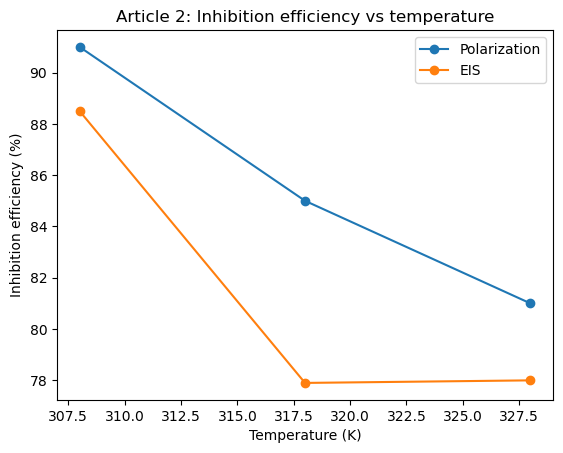

In [28]:
for method in article2_clean["method"].unique():
    subset = article2_clean[article2_clean["method"] == method]
    plt.plot(subset["temperature_K"],subset["inhibition_efficiency_percent"],marker="o",label=method)

plt.xlabel("Temperature (K)")
plt.ylabel("Inhibition efficiency (%)")
plt.title("Article 2: Inhibition efficiency vs temperature")
plt.legend()
plt.show()

## Article 2: Inhibition efficiency vs temperature

The inhibition efficiency decreases as temperature increases from 308 K to 328 K.

For polarization data, the inhibition efficiency decreases from about 91% at 308 K to about 81% at 328 K.

For EIS data, the inhibition efficiency decreases from about 88.5% at 308 K to about 78% at higher temperatures. The EIS values remain almost stable between 318 K and 328 K.

This trend suggests that the protective adsorption layer becomes less effective at higher temperature, which is consistent with a temperature-sensitive adsorption process.

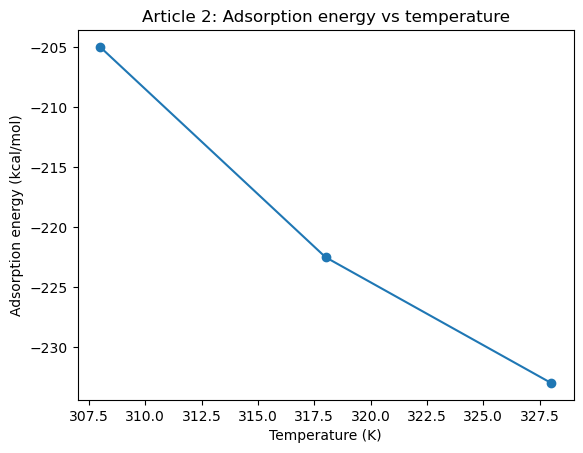

In [29]:
plt.plot(article2_clean_sorted["temperature_K"].drop_duplicates(),
         article2_clean_sorted.drop_duplicates("temperature_K")["adsorption_energy_kcal_mol"],marker="o")

plt.xlabel("Temperature (K)")
plt.ylabel("Adsorption energy (kcal/mol)")
plt.title("Article 2: Adsorption energy vs temperature")
plt.show()

## Article 2: Adsorption energy vs temperature

The adsorption energy becomes more negative as temperature increases from 308 K to 328 K.

This trend suggests stronger predicted adsorption in the simulation data at higher temperature. However, this trend does not directly match the experimental inhibition efficiency, which decreases with increasing temperature.

Therefore, adsorption energy alone cannot fully explain the corrosion inhibition performance. The experimental efficiency is likely affected by additional temperature-dependent electrochemical factors, such as faster corrosion kinetics, protective film stability, and possible differences between simulation and experimental conditions.

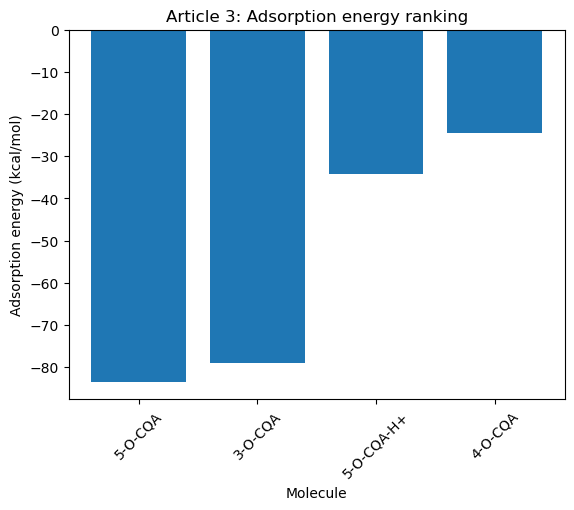

In [30]:
article3_clean_sorted = article3_clean.sort_values(by="adsorption_energy_kcal_mol")

plt.bar(article3_clean_sorted["molecule_name"],article3_clean_sorted["adsorption_energy_kcal_mol"])

plt.xlabel("Molecule")
plt.ylabel("Adsorption energy (kcal/mol)")
plt.title("Article 3: Adsorption energy ranking")
plt.xticks(rotation=45)
plt.show()

## Article 3: Adsorption energy ranking

The adsorption energy ranking shows that 5-O-CQA has the strongest predicted adsorption on the Fe(110) surface, followed by 3-O-CQA, 5-O-CQA-H+, and 4-O-CQA.

Because more negative adsorption energy generally indicates stronger adsorption, 5-O-CQA can be considered the strongest adsorption candidate based on the MD/MC simulation data.

However, adsorption energy alone should not be used as the only criterion. Other quantum chemical descriptors such as HOMO-LUMO energy gap, hardness, and fraction of electron transfer should also be compared to understand the molecular inhibition behavior more completely.

In [31]:
article3_descriptor_ranking = article3_clean_sorted[["molecule_name",
                                                     "EHOMO_eV",
                                                     "ELUMO_eV",
                                                     "energy_gap_eV",
                                                     "hardness_eV",
                                                     "fraction_electron_transfer_deltaN",
                                                     "adsorption_energy_kcal_mol",
                                                     "adsorption_strength_rank"]]

article3_descriptor_ranking

,molecule_name,EHOMO_eV,ELUMO_eV,energy_gap_eV,hardness_eV,fraction_electron_transfer_deltaN,adsorption_energy_kcal_mol,adsorption_strength_rank
2,5-O-CQA,-5.55,-2.94,2.61,1.30,1.05,-83.41,1.0
0,3-O-CQA,-5.55,-2.96,2.59,1.29,1.05,-78.92,2.0
3,5-O-CQA-H+,-3.46,-2.78,0.67,0.33,5.70,-34.33,3.0
1,4-O-CQA,-5.46,-3.02,2.44,1.22,1.12,-24.46,4.0


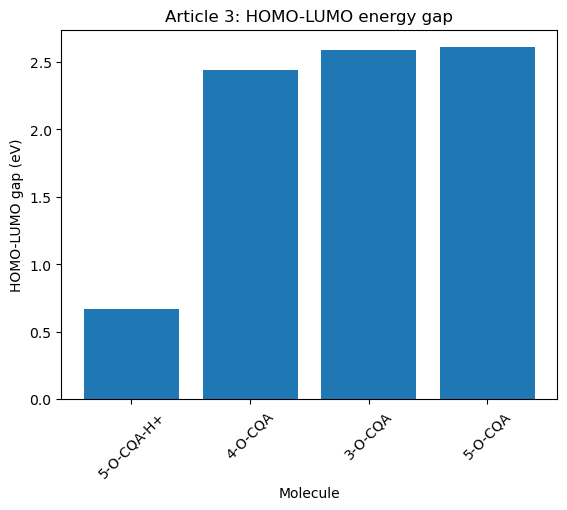

In [32]:
article3_gap_sorted = article3_clean.sort_values(by="energy_gap_eV")

plt.bar(article3_gap_sorted["molecule_name"],article3_gap_sorted["energy_gap_eV"])

plt.xlabel("Molecule")
plt.ylabel("HOMO-LUMO gap (eV)")
plt.title("Article 3: HOMO-LUMO energy gap")
plt.xticks(rotation=45)
plt.show()

## Article 3: HOMO-LUMO energy gap

The HOMO-LUMO energy gap comparison shows that 5-O-CQA-H+ has the lowest energy gap among the studied molecules.

A lower energy gap usually indicates higher electronic reactivity and easier charge-transfer behavior. Therefore, 5-O-CQA-H+ appears to be electronically more reactive than the neutral CQA derivatives.

However, this molecule does not show the strongest adsorption energy. The strongest adsorption energy was observed for 5-O-CQA. This means that adsorption strength and electronic reactivity do not necessarily rank the molecules in the same order.

Therefore, corrosion inhibition behavior should be interpreted using multiple descriptors rather than a single descriptor.

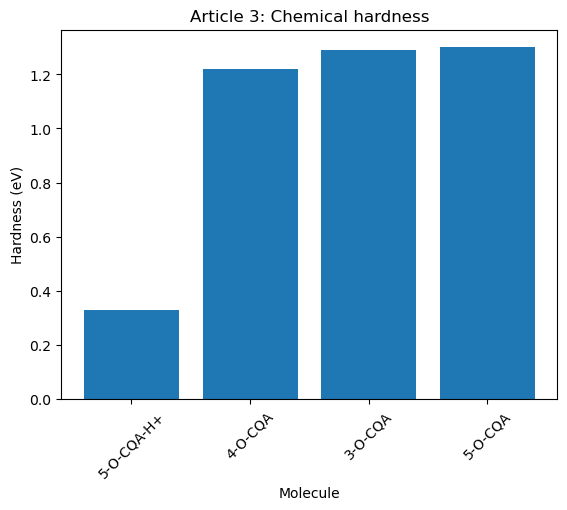

In [36]:
article3_hardness_sorted = article3_clean.sort_values(by="hardness_eV")

plt.bar(article3_hardness_sorted["molecule_name"],article3_hardness_sorted["hardness_eV"])

plt.xlabel("Molecule")
plt.ylabel("Hardness (eV)")
plt.title("Article 3: Chemical hardness")
plt.xticks(rotation=45)
plt.show()

## Article 3: Chemical hardness

The chemical hardness plot shows that 5-O-CQA-H+ has the lowest hardness among the studied molecules.

Lower hardness usually indicates higher molecular softness and higher electronic reactivity. Therefore, 5-O-CQA-H+ appears to be the most electronically reactive molecule in this dataset.

However, this molecule does not have the strongest adsorption energy. The strongest adsorption energy was observed for 5-O-CQA. This confirms that adsorption strength and electronic reactivity should be interpreted together rather than separately.

In [37]:
article3_final_comparison = article3_clean[[
        "molecule_name","energy_gap_eV",
        "hardness_eV","fraction_electron_transfer_deltaN",
        "adsorption_energy_kcal_mol",
        "adsorption_strength_rank"]].sort_values(by="adsorption_strength_rank")

article3_final_comparison

,molecule_name,energy_gap_eV,hardness_eV,fraction_electron_transfer_deltaN,adsorption_energy_kcal_mol,adsorption_strength_rank
2,5-O-CQA,2.61,1.30,1.05,-83.41,1.0
0,3-O-CQA,2.59,1.29,1.05,-78.92,2.0
3,5-O-CQA-H+,0.67,0.33,5.70,-34.33,3.0
1,4-O-CQA,2.44,1.22,1.12,-24.46,4.0


In [43]:
article3_comparison_file = reports_path / "article3_descriptor_adsorption_comparison.csv"

article3_final_comparison.to_csv(article3_comparison_file, index=False)

print("Article 3 comparison table saved:")
print(article3_comparison_file)
print("File exists:", article3_comparison_file.exists())

Article 3 comparison table saved:
D:\AI\ai-corrosion-roadmap\project2_descriptor\reports\article3_descriptor_adsorption_comparison.csv
File exists: True


## Article 3: Final descriptor comparison table

The final Article 3 comparison table was created and saved in the reports folder.

The table ranks the CQA derivatives based on adsorption strength and compares this ranking with important quantum chemical descriptors.

Based on adsorption energy, 5-O-CQA shows the strongest predicted adsorption on Fe(110). However, 5-O-CQA-H+ shows the lowest energy gap and lowest hardness, indicating the highest electronic reactivity.

This confirms that adsorption strength and electronic reactivity do not necessarily follow the same molecular ranking. Therefore, the inhibition behavior should be interpreted as a multi-descriptor phenomenon.

In [48]:
article3_correlation_columns = ["EHOMO_eV","ELUMO_eV",
                                "energy_gap_eV","hardness_eV",
                                "fraction_electron_transfer_deltaN","adsorption_energy_kcal_mol"]
article3_correlations = article3_clean[article3_correlation_columns].corr()
article3_correlations

,EHOMO_eV,ELUMO_eV,energy_gap_eV,hardness_eV,fraction_electron_transfer_deltaN,adsorption_energy_kcal_mol
EHOMO_eV,1.000000,0.929317,-0.999200,-0.999387,0.999638,0.498254
ELUMO_eV,0.929317,1.000000,-0.913809,-0.915831,0.938681,0.146332
energy_gap_eV,-0.999200,-0.913809,1.000000,0.999987,-0.997789,-0.532139
hardness_eV,-0.999387,-0.915831,0.999987,1.000000,-0.998114,-0.527801
fraction_electron_transfer_deltaN,0.999638,0.938681,-0.997789,-0.998114,1.000000,0.474807
adsorption_energy_kcal_mol,0.498254,0.146332,-0.532139,-0.527801,0.474807,1.000000


In [49]:
article3_adsorption_correlations = article3_correlations["adsorption_energy_kcal_mol"].sort_values()

article3_adsorption_correlations

energy_gap_eV                       -0.532139
hardness_eV                         -0.527801
ELUMO_eV                             0.146332
fraction_electron_transfer_deltaN    0.474807
EHOMO_eV                             0.498254
adsorption_energy_kcal_mol           1.000000
Name: adsorption_energy_kcal_mol, dtype: float64

Because the dataset contains only four molecules, the correlation values should be interpreted only as exploratory indicators, not as statistically strong conclusions.

## Article 3: Correlation analysis

The correlation analysis was performed to explore possible relationships between quantum chemical descriptors and adsorption energy.

In this small dataset, energy gap and hardness show a moderate negative correlation with adsorption energy, while EHOMO and fraction of electron transfer show moderate positive correlations.

However, adsorption energy values are negative, so the sign of the correlation must be interpreted carefully. More negative adsorption energy indicates stronger adsorption.

Because the dataset contains only four molecules, these correlations should be interpreted only as exploratory indicators, not as statistically strong conclusions.

In [50]:
article2_correlation_columns = ["temperature_K","EHOMO_eV","ELUMO_eV",
                                "energy_gap_eV","hardness_eV",
                                "fraction_electron_transfer_deltaN",
                                "adsorption_energy_kcal_mol","inhibition_efficiency_percent"]
article2_correlations = article2_clean[article2_correlation_columns].corr()
article2_correlations

,temperature_K,EHOMO_eV,ELUMO_eV,energy_gap_eV,hardness_eV,fraction_electron_transfer_deltaN,adsorption_energy_kcal_mol,inhibition_efficiency_percent
temperature_K,1.000000,-0.107285,-0.005786,0.344497,0.346814,-0.240621,-0.989612,-0.833214
EHOMO_eV,-0.107285,1.000000,0.994832,-0.970328,-0.969728,0.990832,0.249105,0.385691
ELUMO_eV,-0.005786,0.994832,1.000000,-0.940765,-0.939925,0.971995,0.149489,0.302836
energy_gap_eV,0.344497,-0.970328,-0.940765,1.000000,0.999997,-0.994098,-0.475884,-0.566818
hardness_eV,0.346814,-0.969728,-0.939925,0.999997,1.000000,-0.993827,-0.478053,-0.568494
fraction_electron_transfer_deltaN,-0.240621,0.990832,0.971995,-0.994098,-0.993827,1.000000,0.377663,0.489753
adsorption_energy_kcal_mol,-0.989612,0.249105,0.149489,-0.475884,-0.478053,0.377663,1.000000,0.867403
inhibition_efficiency_percent,-0.833214,0.385691,0.302836,-0.566818,-0.568494,0.489753,0.867403,1.000000


In [51]:
article2_ie_correlations = article2_correlations["inhibition_efficiency_percent"].sort_values()
article2_ie_correlations

temperature_K                       -0.833214
hardness_eV                         -0.568494
energy_gap_eV                       -0.566818
ELUMO_eV                             0.302836
EHOMO_eV                             0.385691
fraction_electron_transfer_deltaN    0.489753
adsorption_energy_kcal_mol           0.867403
inhibition_efficiency_percent        1.000000
Name: inhibition_efficiency_percent, dtype: float64

Because Article 2 contains only six rows and duplicated temperature points for two experimental methods, these correlations are exploratory only.

## Article 2: Correlation with inhibition efficiency

The correlation analysis shows a strong negative relationship between temperature and inhibition efficiency. This agrees with the previous plot, where inhibition efficiency decreased as temperature increased from 308 K to 328 K.

The adsorption energy shows a positive correlation with inhibition efficiency. However, because adsorption energy values are negative, this must be interpreted carefully. In this dataset, higher inhibition efficiency is associated with less negative adsorption energy, while more negative adsorption energy appears at higher temperature where the experimental inhibition efficiency decreases.

Therefore, adsorption energy alone cannot explain the experimental inhibition efficiency trend. Temperature-dependent corrosion kinetics and protective film stability are likely important additional factors.

Because this dataset contains only six rows and duplicated temperature points for two experimental methods, the correlation values are exploratory only and should not be interpreted as statistically strong conclusions.

## Save correlation results

The correlation results for Article 2 and Article 3 were saved in the reports folder for later use in the project summary.

In [52]:
article2_correlation_file = reports_path / "article2_ie_correlations.csv"
article3_correlation_file = reports_path / "article3_adsorption_correlations.csv"

article2_ie_correlations.to_csv(article2_correlation_file)
article3_adsorption_correlations.to_csv(article3_correlation_file)

print("Article 2 IE correlations saved:")
print(article2_correlation_file)
print("File exists:", article2_correlation_file.exists())

print("Article 3 adsorption correlations saved:")
print(article3_correlation_file)
print("File exists:", article3_correlation_file.exists())

Article 2 IE correlations saved:
D:\AI\ai-corrosion-roadmap\project2_descriptor\reports\article2_ie_correlations.csv
File exists: True
Article 3 adsorption correlations saved:
D:\AI\ai-corrosion-roadmap\project2_descriptor\reports\article3_adsorption_correlations.csv
File exists: True


## Save EDA findings report

The main findings from the EDA are summarized and saved as a Markdown report in the reports folder.

In [53]:
eda_findings_file = reports_path / "eda_findings_project2.md"

eda_findings_text = """# EDA Findings — Project 2

## Project title

Descriptor and simulation-based corrosion inhibition analysis of quince-derived inhibitors.

---

## 1. Dataset overview

Two clean datasets were created from the raw descriptor workbook.

### Article 2 clean dataset

File:

`data/processed/article2_clean_temperature_target_v1.csv`

This dataset contains temperature-dependent data for 4-O-CQA / quince extract at 308, 318, and 328 K.

Each temperature appears twice because two experimental methods were used:

- Polarization
- EIS

Dataset shape:

- 6 rows
- 43 columns

### Article 3 clean dataset

File:

`data/processed/article3_clean_molecular_ranking_v1.csv`

This dataset contains molecule-level QM descriptors and adsorption energies for four CQA derivatives:

- 3-O-CQA
- 4-O-CQA
- 5-O-CQA
- 5-O-CQA-H+

Dataset shape:

- 4 rows
- 32 columns

---

## 2. Missing value check

For Article 2, selected key descriptor and target columns were complete, except for method-specific experimental values:

- `icorr` is missing in EIS rows.
- `Rct` is missing in polarization rows.

This is expected because `icorr` belongs to polarization measurements, while `Rct` belongs to EIS measurements.

For Article 3, the selected descriptor and adsorption-energy columns had no missing values.

---

## 3. Article 2: Inhibition efficiency vs temperature

The inhibition efficiency decreases as temperature increases from 308 K to 328 K.

Polarization data show a decrease from about 91% at 308 K to about 81% at 328 K.

EIS data show a decrease from about 88.5% at 308 K to about 78% at higher temperatures. The EIS values are almost stable between 318 K and 328 K.

This suggests that the protective inhibition effect becomes weaker at higher temperature.

---

## 4. Article 2: Adsorption energy vs temperature

The adsorption energy becomes more negative as temperature increases.

This suggests stronger predicted adsorption in the simulation data at higher temperature.

However, this trend does not directly match the experimental inhibition efficiency, which decreases with increasing temperature.

Therefore, adsorption energy alone cannot fully explain the experimental inhibition efficiency trend. Temperature-dependent electrochemical kinetics and protective film stability are likely important additional factors.

---

## 5. Article 3: Adsorption energy ranking

Based on adsorption energy, the molecular adsorption strength ranking is:

1. 5-O-CQA
2. 3-O-CQA
3. 5-O-CQA-H+
4. 4-O-CQA

The strongest predicted adsorption on Fe(110) was observed for 5-O-CQA.

---

## 6. Article 3: HOMO-LUMO gap and hardness

5-O-CQA-H+ showed the lowest HOMO-LUMO energy gap and the lowest chemical hardness.

This suggests that 5-O-CQA-H+ has the highest electronic reactivity among the studied molecules.

However, 5-O-CQA-H+ did not show the strongest adsorption energy.

This means that adsorption strength and electronic reactivity do not necessarily follow the same molecular ranking.

---

## 7. Correlation analysis

Correlation analysis was performed as an exploratory step.

### Article 2

Temperature showed a strong negative correlation with inhibition efficiency, consistent with the observed decrease in inhibition efficiency at higher temperature.

Adsorption energy showed a positive correlation with inhibition efficiency, but this must be interpreted carefully because adsorption energy values are negative.

The Article 2 correlation results are exploratory only because the dataset contains only six rows.

### Article 3

Energy gap and hardness showed moderate negative correlations with adsorption energy.

EHOMO and fraction of electron transfer showed moderate positive correlations with adsorption energy.

These correlations are exploratory only because the Article 3 dataset contains only four molecules.

---

## 8. Main scientific conclusion

The EDA suggests that corrosion inhibition behavior cannot be explained by a single descriptor.

Adsorption energy describes molecule-surface interaction strength.

HOMO-LUMO gap and hardness describe electronic reactivity.

Temperature strongly affects experimental inhibition efficiency.

Therefore, this project should be interpreted as a multi-descriptor corrosion inhibition analysis rather than a simple one-feature prediction problem.

---

## 9. Next step

The next step is to build baseline models carefully, with strong attention to the small dataset size and scientific limitations.
"""

eda_findings_file.write_text(eda_findings_text, encoding="utf-8")

print("EDA findings report saved:")
print(eda_findings_file)
print("File exists:", eda_findings_file.exists())

EDA findings report saved:
D:\AI\ai-corrosion-roadmap\project2_descriptor\reports\eda_findings_project2.md
File exists: True
